In [1]:
!pip install -q datasets pandas numpy matplotlib seaborn scikit-learn joblib

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

dataset = load_dataset(
    "gretelai/symptom_to_diagnosis"
)

print(dataset)

README.md:   0%|          | 0.00/2.46k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/171k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/42.5k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/853 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/212 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['output_text', 'input_text'],
        num_rows: 853
    })
    test: Dataset({
        features: ['output_text', 'input_text'],
        num_rows: 212
    })
})


In [5]:
df = dataset["train"].to_pandas()

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (853, 2)

Columns:
['output_text', 'input_text']


,output_text,input_text
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...


In [4]:
print(df.shape)
print(df.columns.tolist())
display(df.head())

(853, 2)
['output_text', 'input_text']


,output_text,input_text
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853 entries, 0 to 852
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   output_text  853 non-null    object
 1   input_text   853 non-null    object
dtypes: object(2)
memory usage: 13.5+ KB
None


In [7]:
print(df.dtypes)

output_text    object
input_text     object
dtype: object


In [8]:
print(df.shape)

(853, 2)


In [9]:
display(df.head(10))

,output_text,input_text
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...
5,common cold,I've been feeling really run down and weak. My...
6,dengue,I have rashes all over my body. I also have a ...
7,dengue,I have been feeling nauseous and have a consta...
8,impetigo,I have a rash around my nose that is red and i...
9,drug reaction,I have a rash on my chest and back and it itch...


In [10]:
print(
    dataset["train"].features
)

{'output_text': Value('string'), 'input_text': Value('string')}


In [11]:
label_feature = dataset["train"].features["label"]

if hasattr(label_feature, "names"):
    label_names = label_feature.names
    print(label_names)
else:
    label_names = None

KeyError: 'label'

In [12]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['output_text', 'input_text'],
        num_rows: 853
    })
    test: Dataset({
        features: ['output_text', 'input_text'],
        num_rows: 212
    })
})


In [13]:
print(dataset["train"].column_names)

['output_text', 'input_text']


In [14]:
print(dataset["train"].features)

{'output_text': Value('string'), 'input_text': Value('string')}


In [15]:
display(df.head())

,output_text,input_text
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...


In [18]:
label_feature = dataset["train"].features["output_text"]

In [19]:
TEXT_COLUMN = "text"
TARGET_COLUMN = "output_text"

In [20]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (853, 2)

Columns:
['output_text', 'input_text']

Data types:
output_text    object
input_text     object
dtype: object

First 5 rows:


,output_text,input_text
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...


In [21]:
print("Missing values:")
print(df[[TEXT_COLUMN, TARGET_COLUMN]].isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:


KeyError: "['text'] not in index"

In [22]:
TEXT_COLUMN = "input_text"
TARGET_COLUMN = "output_text"

print("Text column:", TEXT_COLUMN)
print("Target column:", TARGET_COLUMN)

Text column: input_text
Target column: output_text


In [23]:
print("Dataset columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset columns:
['output_text', 'input_text']

First 5 rows:


,output_text,input_text
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...


In [24]:
print("Missing values:")
print(df[[TEXT_COLUMN, TARGET_COLUMN]].isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
input_text     0
output_text    0
dtype: int64

Duplicate rows:
4


In [25]:
df = df.dropna(
    subset=[TEXT_COLUMN, TARGET_COLUMN]
)

df = df.drop_duplicates()

df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (849, 2)


In [26]:
print("Number of unique diagnoses:", df[TARGET_COLUMN].nunique())

print("\nDiagnosis classes:")
print(df[TARGET_COLUMN].unique())

Number of unique diagnoses: 22

Diagnosis classes:
['cervical spondylosis' 'impetigo' 'urinary tract infection' 'arthritis'
 'dengue' 'common cold' 'drug reaction' 'fungal infection' 'malaria'
 'allergy' 'bronchial asthma' 'varicose veins' 'migraine' 'hypertension'
 'gastroesophageal reflux disease' 'pneumonia' 'psoriasis' 'diabetes'
 'jaundice' 'chicken pox' 'typhoid' 'peptic ulcer disease']


In [27]:
class_counts = df[TARGET_COLUMN].value_counts()

print("Samples per diagnosis:")
print(class_counts)

Samples per diagnosis:
output_text
impetigo                           40
arthritis                          40
dengue                             40
allergy                            40
malaria                            40
drug reaction                      40
hypertension                       40
chicken pox                        40
psoriasis                          40
varicose veins                     40
diabetes                           40
common cold                        39
cervical spondylosis               39
urinary tract infection            39
fungal infection                   39
bronchial asthma                   39
gastroesophageal reflux disease    39
typhoid                            38
peptic ulcer disease               37
pneumonia                          37
migraine                           32
jaundice                           31
Name: count, dtype: int64


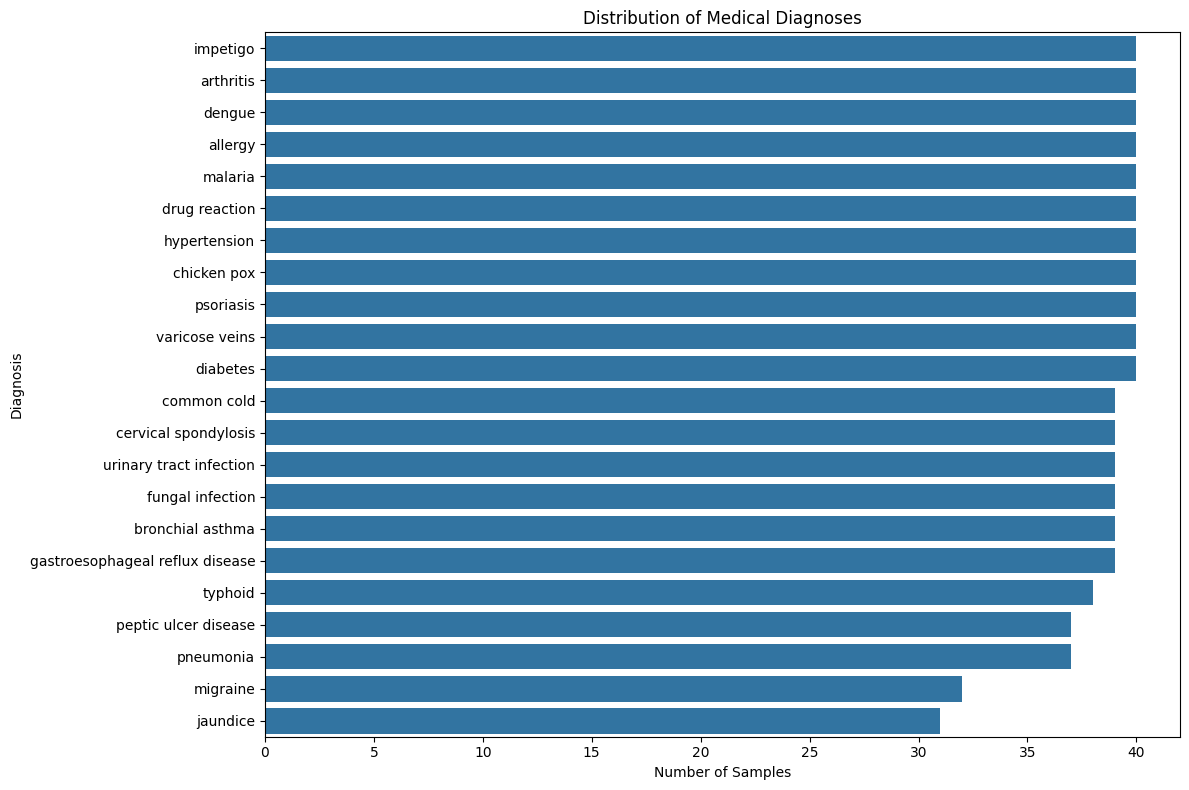

In [28]:
plt.figure(figsize=(12, 8))

sns.countplot(
    data=df,
    y=TARGET_COLUMN,
    order=df[TARGET_COLUMN].value_counts().index
)

plt.title("Distribution of Medical Diagnoses")
plt.xlabel("Number of Samples")
plt.ylabel("Diagnosis")

plt.tight_layout()
plt.show()

In [29]:
df["text_length"] = df[TEXT_COLUMN].astype(str).apply(len)

df["word_count"] = df[TEXT_COLUMN].astype(str).apply(
    lambda x: len(x.split())
)

In [30]:
print("Text Length Statistics:")
print(df["text_length"].describe())

print("\nWord Count Statistics:")
print(df["word_count"].describe())

Text Length Statistics:
count    849.000000
mean     149.967020
std       38.648377
min       55.000000
25%      122.000000
50%      146.000000
75%      174.000000
max      285.000000
Name: text_length, dtype: float64

Word Count Statistics:
count    849.000000
mean      28.868080
std        7.446921
min        8.000000
25%       24.000000
50%       28.000000
75%       33.000000
max       55.000000
Name: word_count, dtype: float64


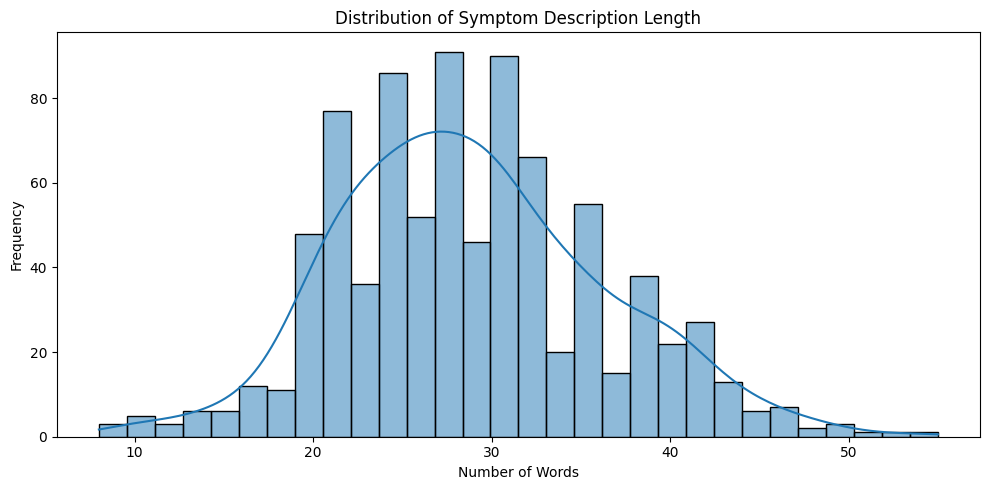

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["word_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Symptom Description Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [32]:
display(
    df[
        [TEXT_COLUMN, TARGET_COLUMN]
    ].sample(
        10,
        random_state=42
    )
)

,input_text,output_text
512,I have rashes on my skin that are itchy and I ...,chicken pox
357,I have a lot of pain in my neck and back. I al...,cervical spondylosis
110,"I've been having neck pain, and I've been feel...",cervical spondylosis
684,I have a rash all over my body and I feel real...,chicken pox
39,"I've been having trouble breathing, coughing, ...",bronchial asthma
66,My genitals are red and irritated. It is often...,psoriasis
756,"I've been feeling really weak and cold lately,...",pneumonia
260,I've been feeling really sick. I have a high f...,malaria
780,I have a rash all over my body that is red and...,fungal infection
467,"I have red, bumpy areas on my skin that are it...",fungal infection


In [33]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [34]:
df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

In [35]:
display(
    df[
        [TEXT_COLUMN, "clean_text", TARGET_COLUMN]
    ].head(10)
)

,input_text,clean_text,output_text
0,I've been having a lot of pain in my neck and ...,i ve been having a lot of pain in my neck and ...,cervical spondylosis
1,I have a rash on my face that is getting worse...,i have a rash on my face that is getting worse...,impetigo
2,I have been urinating blood. I sometimes feel ...,i have been urinating blood i sometimes feel s...,urinary tract infection
3,I have been having trouble with my muscles and...,i have been having trouble with my muscles and...,arthritis
4,I have been feeling really sick. My body hurts...,i have been feeling really sick my body hurts ...,dengue
5,I've been feeling really run down and weak. My...,i ve been feeling really run down and weak my ...,common cold
6,I have rashes all over my body. I also have a ...,i have rashes all over my body i also have a h...,dengue
7,I have been feeling nauseous and have a consta...,i have been feeling nauseous and have a consta...,dengue
8,I have a rash around my nose that is red and i...,i have a rash around my nose that is red and i...,impetigo
9,I have a rash on my chest and back and it itch...,i have a rash on my chest and back and it itch...,drug reaction


In [36]:
X = df["clean_text"]

y = df[TARGET_COLUMN]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nNumber of diagnosis classes:", y.nunique())

X shape: (849,)
y shape: (849,)

Number of diagnosis classes: 22


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 679
Testing samples: 170


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

In [39]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (679, 5000)
Testing TF-IDF shape: (170, 5000)


In [40]:
print(
    "Number of vocabulary terms:",
    len(tfidf.vocabulary_)
)

Number of vocabulary terms: 5000


In [41]:
feature_names = tfidf.get_feature_names_out()

print("First 50 vocabulary terms:")
print(feature_names[:50])

First 50 vocabulary terms:
['abdomen' 'abdomen and' 'abdomen feels' 'abdomen have' 'abdomen hurts'
 'abdomen is' 'abdomen that' 'abdominal' 'abdominal cramps'
 'abdominal pain' 'abdominal part' 'able' 'able to' 'about' 'about bit'
 'about it' 'about my' 'about the' 'about them' 'about this' 'about what'
 'accompanied' 'ache' 'ache for' 'aches' 'aches and' 'aching' 'achy'
 'achy and' 'acid' 'acid reflux' 'acidic' 'acidic also' 'acidic food'
 'activities' 'additionally' 'affect' 'affect my' 'affecting'
 'affecting my' 'after' 'after eat' 'after eating' 'after using'
 'aftertaste' 'all' 'all day' 'all of' 'all over' 'all the']


In [42]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = logistic_model.predict(
    X_test_tfidf
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [43]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = nb_model.predict(
    X_test_tfidf
)

print("Multinomial Naive Bayes trained successfully.")

Multinomial Naive Bayes trained successfully.


In [44]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_tfidf
)

print("Linear SVM trained successfully.")

Linear SVM trained successfully.


In [45]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    loss="hinge",
    max_iter=2000,
    random_state=42
)

sgd_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_sgd = sgd_model.predict(
    X_test_tfidf
)

print("SGD Classifier trained successfully.")

SGD Classifier trained successfully.


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [47]:
def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [48]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr
    )
)

results.append(
    evaluate_model(
        "Multinomial Naive Bayes",
        y_test,
        y_pred_nb
    )
)

results.append(
    evaluate_model(
        "Linear SVM",
        y_test,
        y_pred_svm
    )
)

results.append(
    evaluate_model(
        "SGD Classifier",
        y_test,
        y_pred_sgd
    )
)

In [49]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.947059,0.952992,0.947059,0.946814
1,Linear SVM,0.947059,0.954381,0.947059,0.946712
2,SGD Classifier,0.935294,0.942176,0.935294,0.934284
3,Multinomial Naive Bayes,0.911765,0.919061,0.911765,0.907707


In [50]:
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

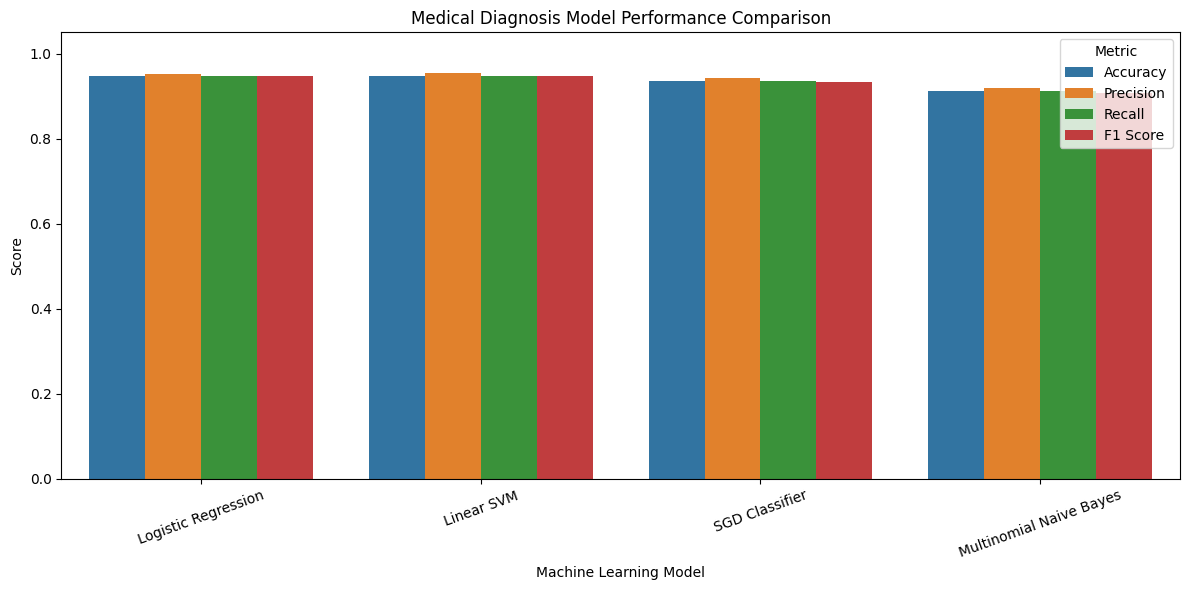

In [51]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1.05)

plt.title(
    "Medical Diagnosis Model Performance Comparison"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [52]:
best_model_name = results_df.iloc[0]["Model"]

best_test_f1 = results_df.iloc[0]["F1 Score"]

print("Best Model:", best_model_name)

print(
    "Best Test F1 Score:",
    round(best_test_f1, 4)
)

Best Model: Logistic Regression
Best Test F1 Score: 0.9468


In [53]:
from sklearn.metrics import classification_report

print("===== LOGISTIC REGRESSION =====")

print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

===== LOGISTIC REGRESSION =====
                                 precision    recall  f1-score   support

                        allergy       1.00      1.00      1.00         8
                      arthritis       1.00      1.00      1.00         8
               bronchial asthma       0.73      1.00      0.84         8
           cervical spondylosis       1.00      1.00      1.00         8
                    chicken pox       0.88      0.88      0.88         8
                    common cold       1.00      1.00      1.00         8
                         dengue       0.88      0.88      0.88         8
                       diabetes       1.00      0.88      0.93         8
                  drug reaction       0.86      0.75      0.80         8
               fungal infection       1.00      1.00      1.00         8
gastroesophageal reflux disease       0.89      1.00      0.94         8
                   hypertension       0.89      1.00      0.94         8
                  

In [54]:
print("===== MULTINOMIAL NAIVE BAYES =====")

print(
    classification_report(
        y_test,
        y_pred_nb,
        zero_division=0
    )
)

===== MULTINOMIAL NAIVE BAYES =====
                                 precision    recall  f1-score   support

                        allergy       1.00      1.00      1.00         8
                      arthritis       0.89      1.00      0.94         8
               bronchial asthma       0.80      1.00      0.89         8
           cervical spondylosis       1.00      1.00      1.00         8
                    chicken pox       0.83      0.62      0.71         8
                    common cold       0.89      1.00      0.94         8
                         dengue       0.88      0.88      0.88         8
                       diabetes       1.00      0.88      0.93         8
                  drug reaction       0.80      0.50      0.62         8
               fungal infection       0.89      1.00      0.94         8
gastroesophageal reflux disease       0.73      1.00      0.84         8
                   hypertension       0.89      1.00      0.94         8
              

In [55]:
print("===== LINEAR SVM =====")

print(
    classification_report(
        y_test,
        y_pred_svm,
        zero_division=0
    )
)

===== LINEAR SVM =====
                                 precision    recall  f1-score   support

                        allergy       0.89      1.00      0.94         8
                      arthritis       1.00      1.00      1.00         8
               bronchial asthma       0.73      1.00      0.84         8
           cervical spondylosis       1.00      1.00      1.00         8
                    chicken pox       0.86      0.75      0.80         8
                    common cold       1.00      1.00      1.00         8
                         dengue       0.78      0.88      0.82         8
                       diabetes       1.00      0.88      0.93         8
                  drug reaction       1.00      0.88      0.93         8
               fungal infection       1.00      1.00      1.00         8
gastroesophageal reflux disease       1.00      1.00      1.00         8
                   hypertension       0.89      1.00      0.94         8
                       impe

In [56]:
print("===== SGD CLASSIFIER =====")

print(
    classification_report(
        y_test,
        y_pred_sgd,
        zero_division=0
    )
)

===== SGD CLASSIFIER =====
                                 precision    recall  f1-score   support

                        allergy       0.89      1.00      0.94         8
                      arthritis       1.00      1.00      1.00         8
               bronchial asthma       0.78      0.88      0.82         8
           cervical spondylosis       1.00      1.00      1.00         8
                    chicken pox       0.86      0.75      0.80         8
                    common cold       1.00      1.00      1.00         8
                         dengue       0.86      0.75      0.80         8
                       diabetes       1.00      0.88      0.93         8
                  drug reaction       1.00      0.88      0.93         8
               fungal infection       1.00      1.00      1.00         8
gastroesophageal reflux disease       1.00      1.00      1.00         8
                   hypertension       0.89      1.00      0.94         8
                       

In [57]:
model_predictions = {
    "Logistic Regression": (
        logistic_model,
        y_pred_lr
    ),

    "Multinomial Naive Bayes": (
        nb_model,
        y_pred_nb
    ),

    "Linear SVM": (
        svm_model,
        y_pred_svm
    ),

    "SGD Classifier": (
        sgd_model,
        y_pred_sgd
    )
}

In [58]:
best_model_name = results_df.iloc[0]["Model"]

best_model, best_predictions = model_predictions[
    best_model_name
]

print("Selected model:", best_model_name)

Selected model: Logistic Regression


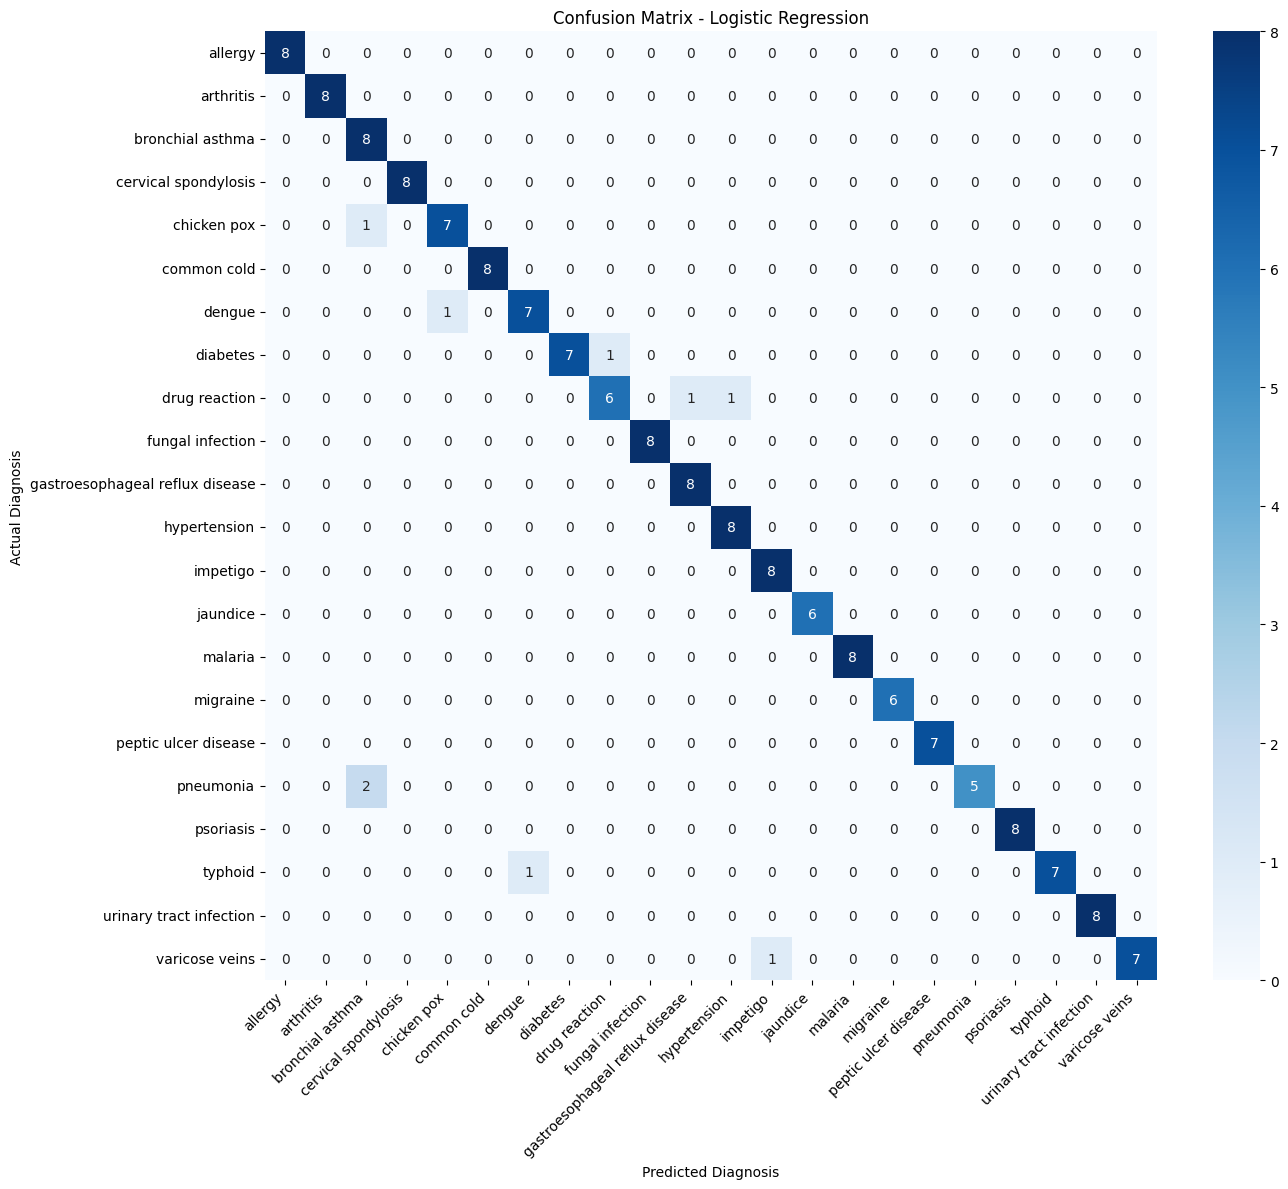

In [59]:
from sklearn.metrics import confusion_matrix

class_labels = sorted(
    y.unique()
)

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=class_labels
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Diagnosis")

plt.ylabel("Actual Diagnosis")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

In [60]:
print(
    f"Classification Report - {best_model_name}"
)

print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

Classification Report - Logistic Regression
                                 precision    recall  f1-score   support

                        allergy       1.00      1.00      1.00         8
                      arthritis       1.00      1.00      1.00         8
               bronchial asthma       0.73      1.00      0.84         8
           cervical spondylosis       1.00      1.00      1.00         8
                    chicken pox       0.88      0.88      0.88         8
                    common cold       1.00      1.00      1.00         8
                         dengue       0.88      0.88      0.88         8
                       diabetes       1.00      0.88      0.93         8
                  drug reaction       0.86      0.75      0.80         8
               fungal infection       1.00      1.00      1.00         8
gastroesophageal reflux disease       0.89      1.00      0.94         8
                   hypertension       0.89      1.00      0.94         8
      

In [61]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [62]:
lr_cv = cross_val_score(
    logistic_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("Logistic Regression")
print("Scores:", lr_cv)
print("Mean:", lr_cv.mean())
print("Std:", lr_cv.std())

Logistic Regression
Scores: [0.92667749 0.85840273 0.89611247 0.92592155 0.90892903]
Mean: 0.9032086527307115
Std: 0.025128912594422417


In [63]:
nb_cv = cross_val_score(
    nb_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("Multinomial Naive Bayes")
print("Scores:", nb_cv)
print("Mean:", nb_cv.mean())
print("Std:", nb_cv.std())

Multinomial Naive Bayes
Scores: [0.87734844 0.82916603 0.86604215 0.90272565 0.85144315]
Mean: 0.865345086702353
Std: 0.02467411924741484


In [64]:
svm_cv = cross_val_score(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("Linear SVM")
print("Scores:", svm_cv)
print("Mean:", svm_cv.mean())
print("Std:", svm_cv.std())

Linear SVM
Scores: [0.96243487 0.86699518 0.91824964 0.92592155 0.93886558]
Mean: 0.922493362846304
Std: 0.03153786135537028


In [65]:
sgd_cv = cross_val_score(
    sgd_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring="f1_weighted"
)

print("SGD Classifier")
print("Scores:", sgd_cv)
print("Mean:", sgd_cv.mean())
print("Std:", sgd_cv.std())

SGD Classifier
Scores: [0.95508193 0.88835225 0.88583671 0.92611408 0.93314685]
Mean: 0.9177063655298949
Std: 0.026770766792989523


In [66]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "SGD Classifier"
    ],

    "Mean CV F1": [
        lr_cv.mean(),
        nb_cv.mean(),
        svm_cv.mean(),
        sgd_cv.mean()
    ],

    "Std CV F1": [
        lr_cv.std(),
        nb_cv.std(),
        svm_cv.std(),
        sgd_cv.std()
    ]
})

cv_results = cv_results.sort_values(
    by="Mean CV F1",
    ascending=False
).reset_index(drop=True)

display(cv_results)

,Model,Mean CV F1,Std CV F1
0,Linear SVM,0.922493,0.031538
1,SGD Classifier,0.917706,0.026771
2,Logistic Regression,0.903209,0.025129
3,Multinomial Naive Bayes,0.865345,0.024674


In [67]:
final_model_name = cv_results.iloc[0]["Model"]

print(
    "Final selected model:",
    final_model_name
)

print(
    "Mean CV F1:",
    round(
        cv_results.iloc[0]["Mean CV F1"],
        4
    )
)

Final selected model: Linear SVM
Mean CV F1: 0.9225


In [68]:
final_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    sublinear_tf=True
)

In [69]:
X_all_tfidf = final_tfidf.fit_transform(
    df["clean_text"]
)

y_all = df[TARGET_COLUMN]

print("Final training data shape:")
print(X_all_tfidf.shape)

Final training data shape:
(849, 5000)


In [70]:
if final_model_name == "Logistic Regression":

    final_classifier = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

elif final_model_name == "Multinomial Naive Bayes":

    final_classifier = MultinomialNB()

elif final_model_name == "Linear SVM":

    final_classifier = LinearSVC(
        random_state=42
    )

elif final_model_name == "SGD Classifier":

    final_classifier = SGDClassifier(
        loss="hinge",
        max_iter=2000,
        random_state=42
    )

else:

    raise ValueError(
        "Unknown model selected"
    )

In [71]:
final_classifier.fit(
    X_all_tfidf,
    y_all
)

print(
    "Final classifier trained successfully."
)

Final classifier trained successfully.


In [72]:
from sklearn.pipeline import Pipeline

In [73]:
medical_pipeline = Pipeline([

    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True
        )
    ),

    (
        "classifier",
        final_classifier
    )
])

In [74]:
def predict_diagnosis(symptoms):

    cleaned_symptoms = clean_text(
        symptoms
    )

    prediction = medical_pipeline.predict(
        [cleaned_symptoms]
    )

    return prediction[0]

In [75]:
sample_symptoms = """
I have fever, cough, sore throat and body pain
"""

result = predict_diagnosis(
    sample_symptoms
)

print("Symptoms:")
print(sample_symptoms)

print("\nPredicted Diagnosis:")
print(result)

NotFittedError: Pipeline is not fitted yet.

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier

if final_model_name == "Logistic Regression":

    final_classifier = LogisticRegression(
        max_iter=2000,
        random_state=42
    )

elif final_model_name == "Multinomial Naive Bayes":

    final_classifier = MultinomialNB()

elif final_model_name == "Linear SVM":

    final_classifier = LinearSVC(
        random_state=42
    )

elif final_model_name == "SGD Classifier":

    final_classifier = SGDClassifier(
        loss="hinge",
        max_iter=2000,
        random_state=42
    )

else:
    raise ValueError(
        f"Unknown model: {final_model_name}"
    )

print("Final classifier:", final_classifier)

Final classifier: LinearSVC(random_state=42)


In [77]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

medical_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True
        )
    ),

    (
        "classifier",
        final_classifier
    )
])

print("Pipeline created successfully.")

Pipeline created successfully.


In [78]:
medical_pipeline.fit(
    df["clean_text"],
    df[TARGET_COLUMN]
)

print("Medical Diagnostics pipeline fitted successfully.")

Medical Diagnostics pipeline fitted successfully.


In [79]:
print(medical_pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=5000,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier', LinearSVC(random_state=42))])


In [80]:
print(
    "Vocabulary size:",
    len(
        medical_pipeline
        .named_steps["tfidf"]
        .vocabulary_
    )
)

Vocabulary size: 5000


In [81]:
def clean_text(text):
    import re

    text = str(text).lower()

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


def predict_diagnosis(symptoms):

    cleaned_symptoms = clean_text(
        symptoms
    )

    prediction = medical_pipeline.predict(
        [cleaned_symptoms]
    )

    return prediction[0]

In [82]:
sample_symptoms = """
I have fever, cough, sore throat and body pain
"""

result = predict_diagnosis(
    sample_symptoms
)

print("Symptoms:")
print(sample_symptoms)

print("\nPredicted Diagnosis:")
print(result)

Symptoms:

I have fever, cough, sore throat and body pain


Predicted Diagnosis:
allergy


In [83]:
test_cases = [
    "fever cough sore throat body pain",
    "headache nausea sensitivity to light",
    "itchy skin red rash and irritation",
    "stomach pain vomiting and diarrhea",
    "joint pain swelling and stiffness"
]

for symptoms in test_cases:

    prediction = predict_diagnosis(
        symptoms
    )

    print("=" * 60)
    print("Symptoms:", symptoms)
    print("Predicted Diagnosis:", prediction)

Symptoms: fever cough sore throat body pain
Predicted Diagnosis: allergy
Symptoms: headache nausea sensitivity to light
Predicted Diagnosis: migraine
Symptoms: itchy skin red rash and irritation
Predicted Diagnosis: psoriasis
Symptoms: stomach pain vomiting and diarrhea
Predicted Diagnosis: typhoid
Symptoms: joint pain swelling and stiffness
Predicted Diagnosis: psoriasis


In [84]:
import joblib

model_path = "/content/medical_diagnosis_model.pkl"

joblib.dump(
    medical_pipeline,
    model_path
)

print("Model saved successfully.")
print(model_path)

Model saved successfully.
/content/medical_diagnosis_model.pkl


In [85]:
import os

print(
    "File exists:",
    os.path.exists(model_path)
)

print(
    "File size:",
    round(
        os.path.getsize(model_path) / 1024,
        2
    ),
    "KB"
)

File exists: True
File size: 1056.59 KB


In [86]:
loaded_model = joblib.load(
    "/content/medical_diagnosis_model.pkl"
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [87]:
test_symptoms = """
I have fever, cough and sore throat
"""

prediction = loaded_model.predict(
    [clean_text(test_symptoms)]
)

print("Symptoms:")
print(test_symptoms)

print("\nPredicted Diagnosis:")
print(prediction[0])

Symptoms:

I have fever, cough and sore throat


Predicted Diagnosis:
common cold
